In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import zero_one_loss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

X_train_full = train_df.iloc[:, 1:].values
y_train_full = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values


train_mask = y_train_full <= 4
X_train_filtered = X_train_full[train_mask]
y_train_filtered = y_train_full[train_mask]

test_mask = y_test <= 4
X_test_filtered = X_test[test_mask]
y_test_filtered = y_test[test_mask]


X_train_filtered = X_train_filtered / 255.0
X_test_filtered = X_test_filtered / 255.0


X_train, X_val, y_train, y_val = train_test_split(
    X_train_filtered, 
    y_train_filtered, 
    test_size=0.10, 
    random_state=42
)

mlp = MLPClassifier(
    hidden_layer_sizes=(16, 32), 
    learning_rate_init=0.0001,    
    max_iter=1000,               
    batch_size=100,              
    random_state=42
)


mlp.fit(X_train, y_train)


train_error = 1 - mlp.score(X_train, y_train)
val_error = 1 - mlp.score(X_val, y_val)
test_error = 1 - mlp.score(X_test_filtered, y_test_filtered)

print(f"Training Error: {train_error:.4f}")
print(f"Validation Error: {val_error:.4f}")
print(f"Testing Error: {test_error:.4f}")

Training Error: 0.8065
Validation Error: 0.7938
Testing Error: 0.7992


## Different learning rate values/ Batch sizes

Training with learning rate: 0.0001
Training with learning rate: 0.001
Training with learning rate: 0.01
Training with learning rate: 0.1
Training with learning rate: 1.0


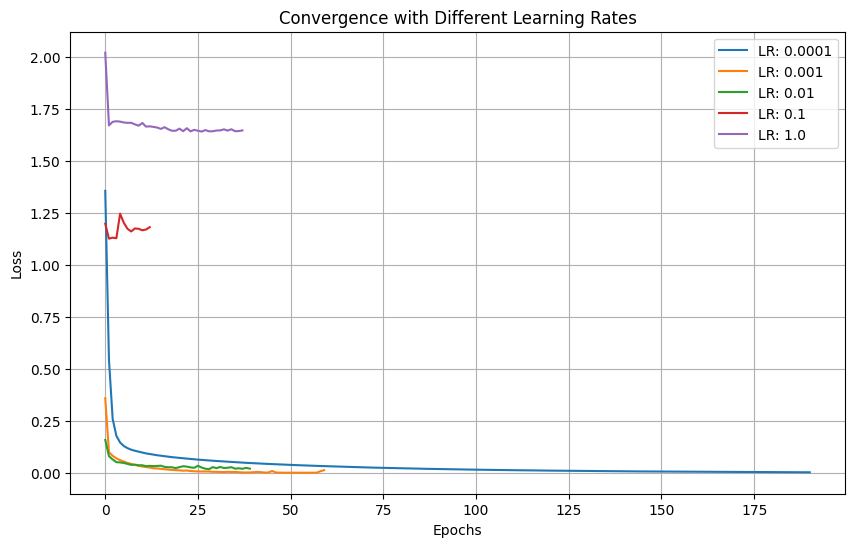

In [9]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    print(f"Training with learning rate: {lr}")
    mlp_lr = MLPClassifier(
        hidden_layer_sizes=(16, 32),
        learning_rate_init=lr,
        max_iter=1000,
        batch_size=100,
        random_state=42
    )
    
   
    mlp_lr.fit(X_train, y_train)
    
  
    plt.plot(mlp_lr.loss_curve_, label=f'LR: {lr}')

plt.title('Convergence with Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('learning_rates_convergence.png')
plt.show()

Training with batch size: 10
Training with batch size: 50
Training with batch size: 100
Training with batch size: 500
Training with batch size: 1000


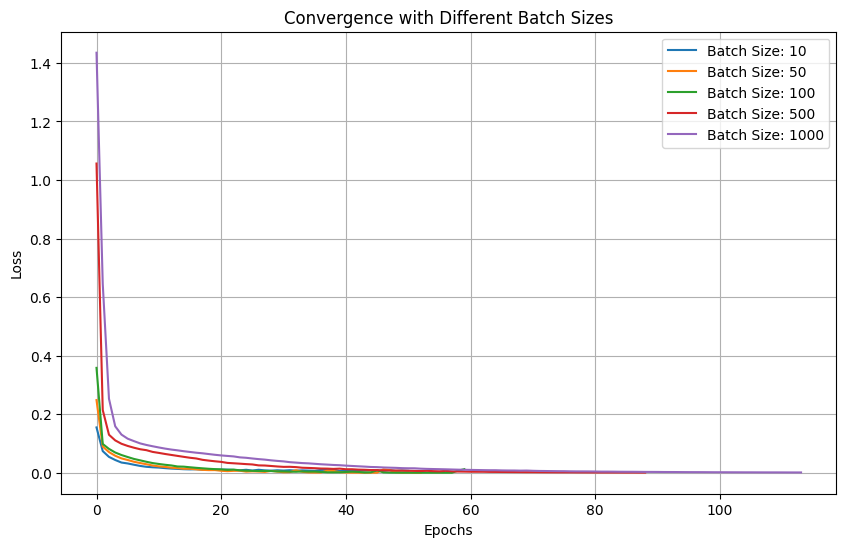

In [10]:
# 5 different mini-batch sizes from 10 to 1000
batch_sizes = [10, 50, 100, 500, 1000]

plt.figure(figsize=(10, 6))

for bs in batch_sizes:
    print(f"Training with batch size: {bs}")
   
    mlp_bs = MLPClassifier(
        hidden_layer_sizes=(16, 32),
        learning_rate_init=0.001,
        max_iter=1000,
        batch_size=bs,
        random_state=42
    )
    
    mlp_bs.fit(X_train, y_train)
    
   
    plt.plot(mlp_bs.loss_curve_, label=f'Batch Size: {bs}')

plt.title('Convergence with Different Batch Sizes')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('batch_sizes_convergence.png')
plt.show()

###  Learning rate
- Low (0.0001): Highly stable but extremely slow
- Optimal (0.001-0.01): Loss drios quickly and soothly levels off, finding a minimum efficiently 
- High (0.1-1.0): Convergence is chaotic and unstable, the model constantly overshoots the optimal minimum

### Mini-batch size
- Small (10, 50, 100) These converge quickly in very few epochs
- Larger batches (500,1000) These require significantly more epochs to converge

- To choose the best value, you should balance the number of epochs needed to converge against the computational efficiency

## Different number of hidden units

Training with hidden layers: (5, 5)
Test Accuracy for (5, 5): 0.9652
Training with hidden layers: (50, 50)
Test Accuracy for (50, 50): 0.9936
Training with hidden layers: (100, 100)
Test Accuracy for (100, 100): 0.9940


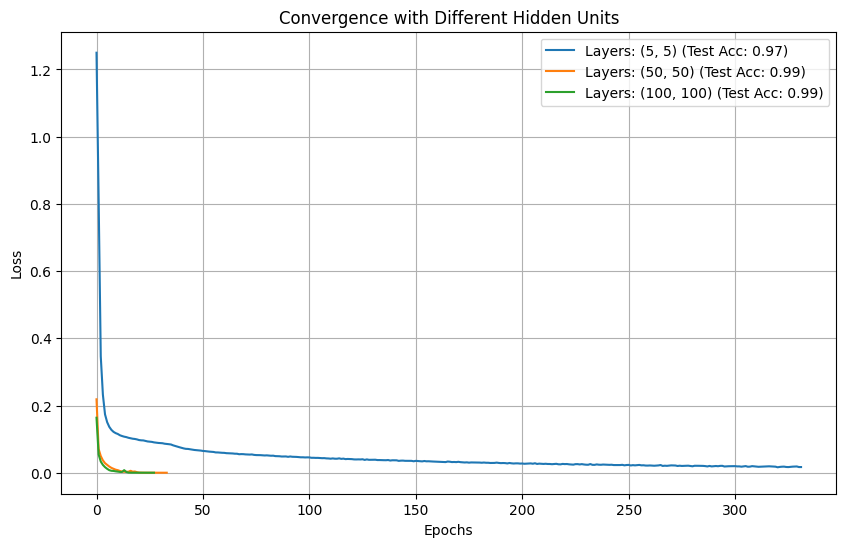

In [11]:
hidden_configs = [(5, 5), (50, 50), (100, 100)]

plt.figure(figsize=(10, 6))

for config in hidden_configs:
    print(f"Training with hidden layers: {config}")
    mlp_hidden = MLPClassifier(
        hidden_layer_sizes=config,
        learning_rate_init=0.001,
        max_iter=1000, 
        batch_size=100,
        random_state=42
    )
    
    mlp_hidden.fit(X_train, y_train)
    
   
    test_acc = mlp_hidden.score(X_test_filtered, y_test_filtered)
    print(f"Test Accuracy for {config}: {test_acc:.4f}")
    
    plt.plot(mlp_hidden.loss_curve_, label=f'Layers: {config} (Test Acc: {test_acc:.2f})')

plt.title('Convergence with Different Hidden Units')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('hidden_units_convergence.png')
plt.show()

- Low capacity (5,5): Convergence is significantly slower and initial loss is very high
  - The network acheives a lower test accuracy (0.97) indicating the sligly less capacity to model the data
- High capacity (50,50 & 100,100): Convergence ins extremely rapid and initial loss is much lower
  - Achieves a higher test acuracy of 0.99

## Confusion matrix

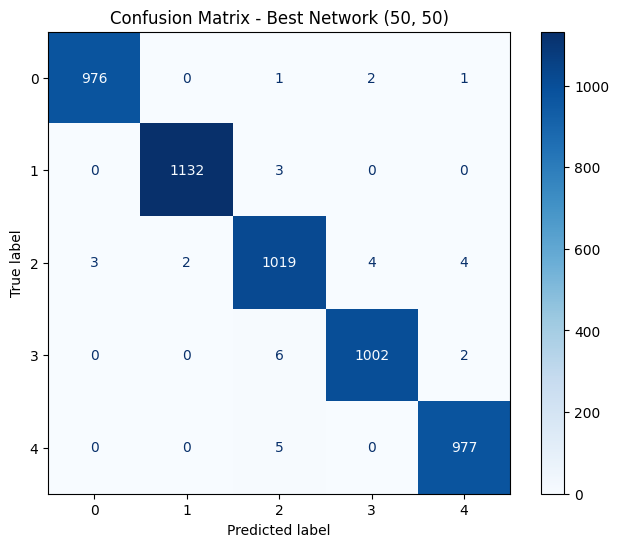

In [15]:
best_mlp = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    learning_rate_init=0.001,
    max_iter=1000, 
    batch_size=100,
    random_state=42
)
best_mlp.fit(X_train, y_train)


y_pred = best_mlp.predict(X_test_filtered)


cm = confusion_matrix(y_test_filtered, y_pred, labels=best_mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_mlp.classes_)


fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix - Best Network (50, 50)')
plt.savefig('confusion_matrix_part1d.png')
plt.show()